# vLLM Single Run Analysis

In [13]:
# ============================================================
#  Configuration — edit here only
# ============================================================
RESULTS_DIR = "/mnt/d/projects/vllm_hybrid/eval/results"
RUN_NAME    = "20260329_100123"   # timestamp directory name
# ============================================================

import json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

GPU_COLOR    = '#4C72B0'   # seaborn muted blue
HYBRID_COLOR = '#DD8452'   # seaborn muted orange
PALETTE      = {'GPU-only': GPU_COLOR, 'Hybrid': HYBRID_COLOR}

# ── Data loading ─────────────────────────────────────────────
run_dir = Path(RESULTS_DIR) / RUN_NAME

def load_json(name):
    p = run_dir / name
    return json.load(open(p)) if p.exists() else None

def load_csv(name):
    p = run_dir / name
    if not p.exists(): return None
    df = pd.read_csv(p)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

gpu_only   = load_json('gpu_only.json')
hybrid     = load_json('hybrid.json')
comparison = load_json('comparison.json')
g_gpu_csv  = load_csv('gpu_only_monitor_gpu.csv')
g_cpu_csv  = load_csv('gpu_only_monitor_cpu.csv')
h_gpu_csv  = load_csv('hybrid_monitor_gpu.csv')
h_cpu_csv  = load_csv('hybrid_monitor_cpu.csv')

model = (hybrid or gpu_only or {}).get('model_id', '?')
print(f"Run        : {RUN_NAME}")
print(f"Model      : {model}")
print(f"Available  : gpu_only={'YES' if gpu_only else 'NO'}  "
      f"hybrid={'YES' if hybrid else 'NO'}  "
      f"comparison={'YES' if comparison else 'NO'}")

Run        : 20260329_100123
Model      : Qwen/Qwen2.5-7B-Instruct
Available  : gpu_only=YES  hybrid=YES  comparison=YES


In [2]:
# ============================================================
#  1. Benchmark Metadata & Config Parameters
# ============================================================

meta_keys = [
    ('date',                 'Benchmark Date'),
    ('backend',              'Backend'),
    ('model_id',             'Model ID'),
    ('tokenizer_id',         'Tokenizer ID'),
    ('num_prompts',          'Num Prompts'),
    ('request_rate',         'Request Rate'),
    ('burstiness',           'Burstiness'),
    ('max_concurrency',      'Max Concurrency'),
    ('completed',            'Completed Requests'),
    ('total_input_tokens',   'Total Input Tokens'),
    ('total_output_tokens',  'Total Output Tokens'),
    ('duration',             'Duration (s)'),
]

rows = []
for key, label in meta_keys:
    g_val = (gpu_only or {}).get(key, '-')
    h_val = (hybrid   or {}).get(key, '-')
    rows.append({'Parameter': label, 'GPU-only': g_val, 'Hybrid': h_val})

meta_df = pd.DataFrame(rows).set_index('Parameter')

def style_meta(df):
    return df.style \
        .set_properties(**{'text-align': 'left', 'font-size': '13px',
                           'border-color': '#e0e0e0'}) \
        .set_table_styles([
            {'selector': 'th',
             'props': [('background-color', '#2d4a7a'), ('color', 'white'),
                       ('font-size', '13px'), ('padding', '6px 12px')]},
            {'selector': 'tr:nth-child(even)',
             'props': [('background-color', '#f5f8ff')]},
            {'selector': 'tr:hover',
             'props': [('background-color', '#dce8ff')]},
        ]) \
        .set_caption('<b style="font-size:15px">Benchmark Metadata & Configuration</b>')

style_meta(meta_df)

,GPU-only,Hybrid
Parameter,,
Benchmark Date,20260327-131243,20260327-131430
Backend,vllm,vllm
Model ID,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-1.5B
Tokenizer ID,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-1.5B
Num Prompts,2000,2000
Request Rate,inf,inf
Burstiness,1.000000,1.000000
Max Concurrency,None,None
Completed Requests,1006,1006


In [3]:
# ============================================================
#  2. Full Performance Metrics Table
# ============================================================

perf_keys = [
    ('request_throughput',     'Request Throughput (req/s)',     'higher'),
    ('request_goodput',        'Request Goodput (req/s)',        'higher'),
    ('output_throughput',      'Output Throughput (tok/s)',      'higher'),
    ('total_token_throughput', 'Total Token Throughput (tok/s)', 'higher'),
    ('duration',               'Duration (s)',                   'lower'),
    ('mean_ttft_ms',           'Mean TTFT (ms)',                 'lower'),
    ('median_ttft_ms',         'Median TTFT (ms)',               'lower'),
    ('std_ttft_ms',            'Std TTFT (ms)',                  'lower'),
    ('p99_ttft_ms',            'P99 TTFT (ms)',                  'lower'),
    ('mean_tpot_ms',           'Mean TPOT (ms)',                 'lower'),
    ('median_tpot_ms',         'Median TPOT (ms)',               'lower'),
    ('std_tpot_ms',            'Std TPOT (ms)',                  'lower'),
    ('p99_tpot_ms',            'P99 TPOT (ms)',                  'lower'),
    ('mean_itl_ms',            'Mean ITL (ms)',                  'lower'),
    ('median_itl_ms',          'Median ITL (ms)',                'lower'),
    ('std_itl_ms',             'Std ITL (ms)',                   'lower'),
    ('p99_itl_ms',             'P99 ITL (ms)',                   'lower'),
]

# diff data lives under comparison['comparison'], not the top level
cmp_sub = (comparison or {}).get('comparison', {})

rows = []
for key, label, better in perf_keys:
    g_val = (gpu_only or {}).get(key)
    h_val = (hybrid   or {}).get(key)
    cmp_entry = cmp_sub.get(key, {})
    diff = cmp_entry.get('diff_pct', np.nan) if isinstance(cmp_entry, dict) else np.nan
    if not np.isnan(diff) and g_val is not None and h_val is not None:
        win = (diff > 0 and better == 'higher') or (diff < 0 and better == 'lower')
        result = '✅ Hybrid' if win else ('❌ Hybrid' if abs(diff) > 0.5 else '➖ Tie')
    else:
        result = '-'
    rows.append({'Metric': label, 'Dir': '↑' if better == 'higher' else '↓',
                 'GPU-only': g_val, 'Hybrid': h_val, 'Diff (%)': diff, 'Winner': result})

perf_df = pd.DataFrame(rows).set_index('Metric')

def color_diff(val):
    if pd.isna(val): return ''
    if val < -0.5:  return 'color: #1a7f3c; font-weight: bold; background-color: #eafaf1'
    if val >  0.5:  return 'color: #c0392b; font-weight: bold; background-color: #fdedec'
    return 'color: #888'

perf_df.style \
    .format({'GPU-only': '{:.3f}', 'Hybrid': '{:.3f}', 'Diff (%)': '{:+.2f}'}, na_rep='-') \
    .applymap(color_diff, subset=['Diff (%)']) \
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#2d4a7a'), ('color', 'white'),
                   ('font-size', '12px'), ('padding', '5px 10px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f9f9f9')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#eef3fb')]},
    ]) \
    .set_caption('<b style="font-size:15px">Full Performance Metrics</b>')


,Dir,GPU-only,Hybrid,Diff (%),Winner
Metric,,,,,
Request Throughput (req/s),↑,19.440,16.859,-13.28,❌ Hybrid
Request Goodput (req/s),↑,-,-,-,-
Output Throughput (tok/s),↑,9737.771,8455.977,-13.16,❌ Hybrid
Total Token Throughput (tok/s),↑,12216.930,10605.932,-13.19,❌ Hybrid
Duration (s),↓,51.748,59.671,+15.31,❌ Hybrid
Mean TTFT (ms),↓,20374.826,22162.712,+8.77,❌ Hybrid
Median TTFT (ms),↓,15625.889,16580.836,+6.11,❌ Hybrid
Std TTFT (ms),↓,14106.449,15917.529,-,-
P99 TTFT (ms),↓,41220.155,45870.112,+11.28,❌ Hybrid


In [4]:
# ============================================================
#  3. Speedup & Overall Comparison Summary
# ============================================================

if not comparison:
    print('comparison.json not found')
else:
    cmp_sub = comparison.get('comparison', {})

    req_speedup = cmp_sub.get('request_throughput_speedup', np.nan)
    out_speedup = cmp_sub.get('output_tok_speedup', np.nan)
    ttft_gain   = cmp_sub.get('ttft_gain_pct', np.nan)

    print(f'  Request Throughput Speedup : {req_speedup:.4f}x')
    print(f'  Output Token Speedup       : {out_speedup:.4f}x')
    print(f'  TTFT Gain (Hybrid vs GPU)  : {ttft_gain:+.2f}%  '
          f"({'worse' if ttft_gain > 0 else 'better'})")

    cmp_rows = []
    for key, val in cmp_sub.items():
        if isinstance(val, dict) and 'diff_pct' in val:
            cmp_rows.append({'Key': key,
                             'Direction': val.get('direction', '-'),
                             'Diff (%)': val['diff_pct']})

    if cmp_rows:
        cmp_df = pd.DataFrame(cmp_rows).set_index('Key')

        def bar_color(val):
            if pd.isna(val): return ''
            if val < -0.5:  return 'color:#1a7f3c; font-weight:bold; background:#eafaf1'
            if val >  0.5:  return 'color:#c0392b; font-weight:bold; background:#fdedec'
            return 'color:#888'

        display(cmp_df.style
            .format({'Diff (%)': '{:+.2f}'})
            .applymap(bar_color, subset=['Diff (%)'])
            .bar(subset=['Diff (%)'], align='zero',
                 color=['#aed6b8', '#f5b7b1'], vmin=-100, vmax=100)
            .set_table_styles([{
                'selector': 'th',
                'props': [('background-color','#2d4a7a'),('color','white'),
                          ('font-size','12px'),('padding','5px 10px')],
            }])
            .set_caption('<b style="font-size:15px">All Diff (%) — Hybrid vs GPU-only</b>'))


  Request Throughput Speedup : 0.8672x
  Output Token Speedup       : 0.8684x
  TTFT Gain (Hybrid vs GPU)  : -8.77%  (better)


,Direction,Diff (%)
Key,,
request_throughput,higher_better,-13.28
output_throughput,higher_better,-13.16
total_token_throughput,higher_better,-13.19
duration,lower_better,+15.31
mean_ttft_ms,lower_better,+8.77
median_ttft_ms,lower_better,+6.11
p99_ttft_ms,lower_better,+11.28
mean_tpot_ms,lower_better,+13.34
median_tpot_ms,lower_better,+14.05


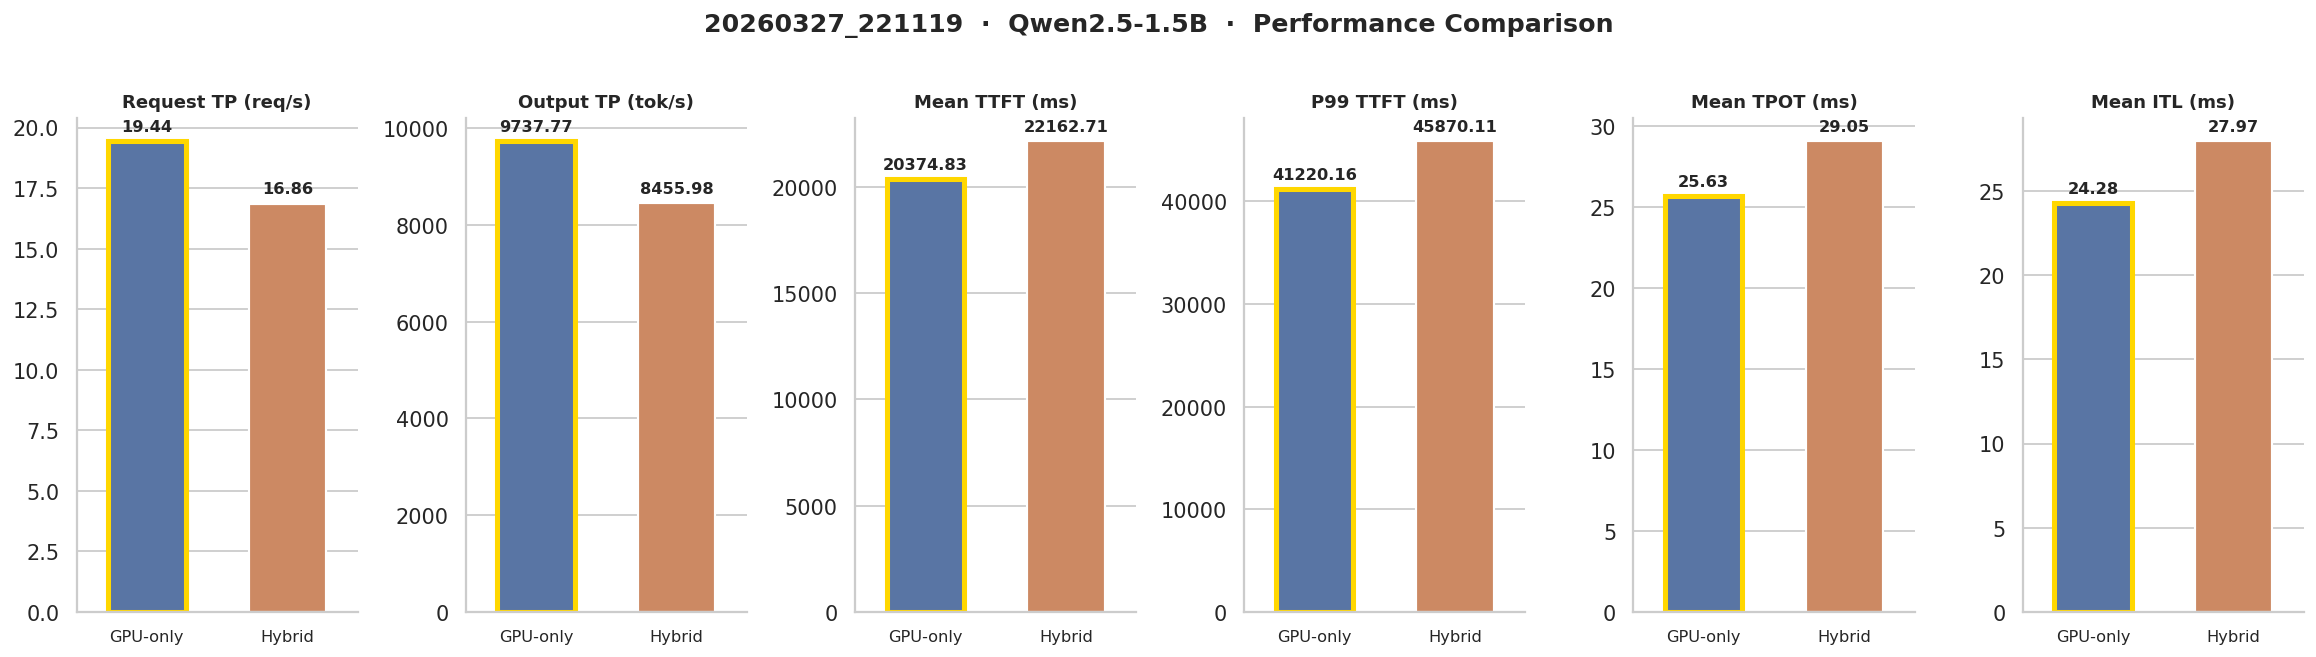

In [5]:
# ============================================================
#  4. Throughput & Latency Bar Charts
# ============================================================

plot_items = [
    ('request_throughput', 'Request TP\n(req/s)',   'higher'),
    ('output_throughput',  'Output TP\n(tok/s)',    'higher'),
    ('mean_ttft_ms',       'Mean TTFT\n(ms)',       'lower'),
    ('p99_ttft_ms',        'P99 TTFT\n(ms)',        'lower'),
    ('mean_tpot_ms',       'Mean TPOT\n(ms)',       'lower'),
    ('mean_itl_ms',        'Mean ITL\n(ms)',        'lower'),
]

# build tidy DataFrame
bar_rows = []
for key, label, better in plot_items:
    g_val = (gpu_only or {}).get(key, 0) or 0
    h_val = (hybrid   or {}).get(key, 0) or 0
    for mode, val in [('GPU-only', g_val), ('Hybrid', h_val)]:
        bar_rows.append({'Metric': label, 'Mode': mode, 'Value': val,
                         'Better': better})
bar_df = pd.DataFrame(bar_rows)

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle(
    f"{RUN_NAME}  ·  {model.split('/')[-1]}  ·  Performance Comparison",
    fontsize=14, fontweight='bold', y=1.01)

for ax, (key, label, better) in zip(axes, plot_items):
    sub = bar_df[bar_df['Metric'] == label]
    g_val = sub[sub['Mode']=='GPU-only']['Value'].values[0]
    h_val = sub[sub['Mode']=='Hybrid']['Value'].values[0]

    g = sns.barplot(data=sub, x='Mode', y='Value', palette=PALETTE,
                    order=['GPU-only','Hybrid'], ax=ax,
                    edgecolor='white', linewidth=1.2, width=0.55)

    # winner highlight
    win_mode = ('GPU-only' if g_val > h_val else 'Hybrid') if better=='higher' \
               else ('GPU-only' if g_val < h_val else 'Hybrid')
    for patch, mode in zip(ax.patches, ['GPU-only','Hybrid']):
        if mode == win_mode:
            patch.set_edgecolor('#FFD700'); patch.set_linewidth(2.8)

    # value labels
    for patch in ax.patches:
        v = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2,
                v + max(g_val, h_val)*0.015,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(label.replace('\n',' '), fontsize=10, fontweight='semibold', pad=6)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

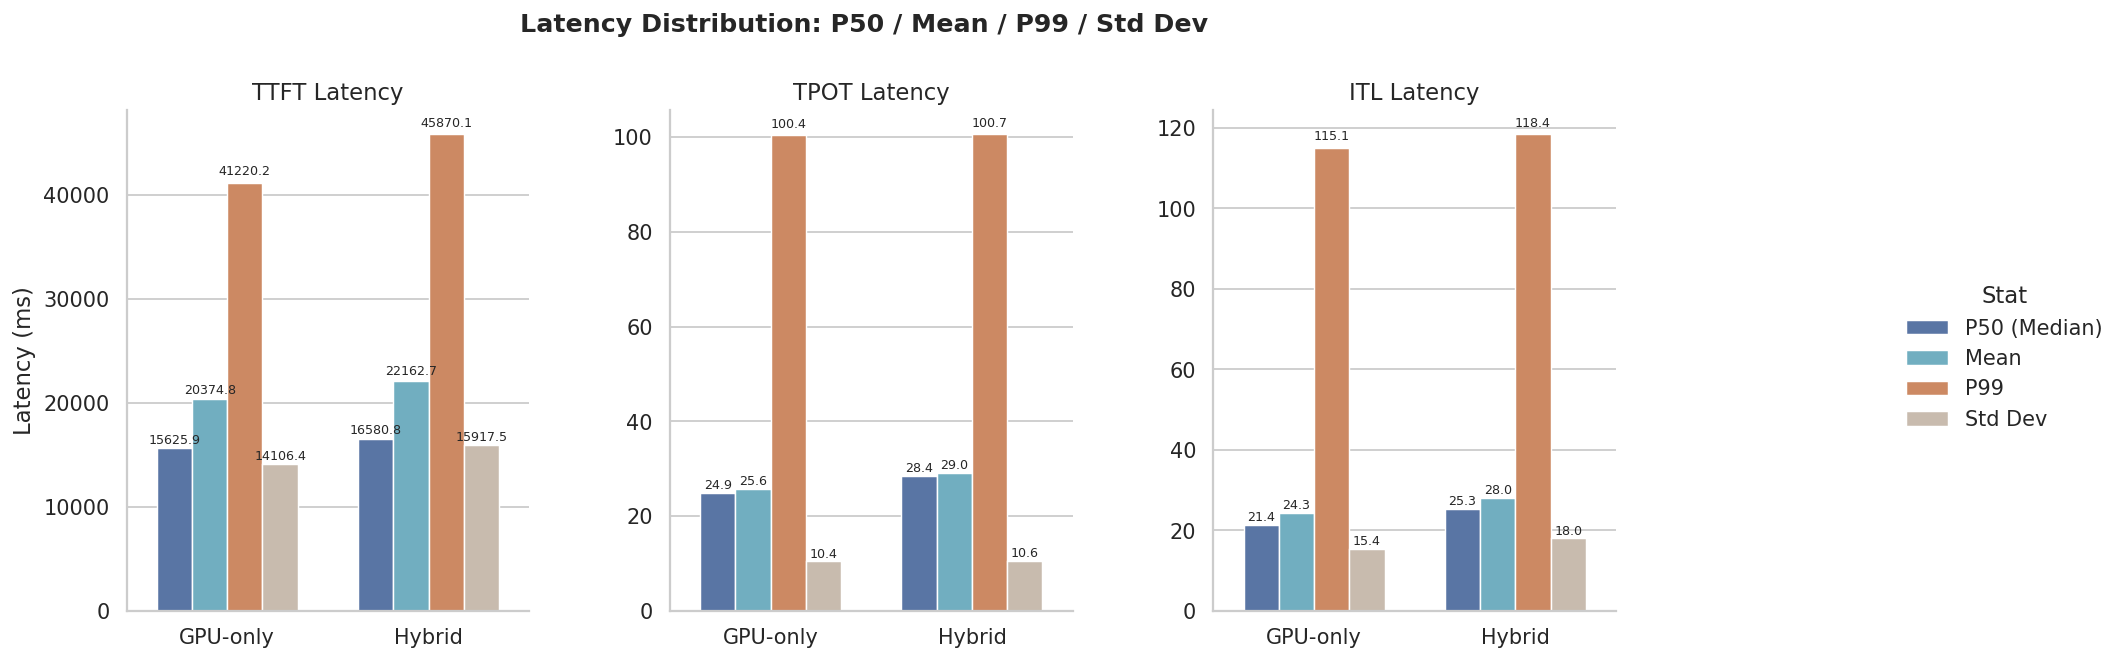

In [6]:
# ============================================================
#  5. Latency Distribution: P50 / P99 / Std
# ============================================================

lat_groups = [
    ('TTFT', 'median_ttft_ms', 'mean_ttft_ms', 'p99_ttft_ms', 'std_ttft_ms'),
    ('TPOT', 'median_tpot_ms', 'mean_tpot_ms', 'p99_tpot_ms', 'std_tpot_ms'),
    ('ITL',  'median_itl_ms',  'mean_itl_ms',  'p99_itl_ms',  'std_itl_ms'),
]

lat_rows = []
for name, p50k, meank, p99k, stdk in lat_groups:
    for mode, src in [('GPU-only', gpu_only), ('Hybrid', hybrid)]:
        if src is None: continue
        lat_rows += [
            {'Metric': name, 'Mode': mode, 'Stat': 'P50 (Median)', 'ms': src.get(p50k, 0) or 0},
            {'Metric': name, 'Mode': mode, 'Stat': 'Mean',         'ms': src.get(meank, 0) or 0},
            {'Metric': name, 'Mode': mode, 'Stat': 'P99',          'ms': src.get(p99k, 0) or 0},
            {'Metric': name, 'Mode': mode, 'Stat': 'Std Dev',      'ms': src.get(stdk, 0) or 0},
        ]
lat_df = pd.DataFrame(lat_rows)

stat_palette = {'P50 (Median)': '#4C72B0', 'Mean': '#64B5CD',
                'P99': '#DD8452',           'Std Dev': '#CCBBAA'}

g = sns.FacetGrid(lat_df, col='Metric', height=5, aspect=0.9,
                  sharey=False, gridspec_kws={'wspace': 0.35})

def draw_grouped(data, **kw):
    ax = plt.gca()
    sns.barplot(data=data, x='Mode', y='ms', hue='Stat',
                palette=stat_palette, order=['GPU-only','Hybrid'],
                hue_order=['P50 (Median)','Mean','P99','Std Dev'],
                edgecolor='white', linewidth=0.8, ax=ax, width=0.7)
    for patch in ax.patches:
        v = patch.get_height()
        if v > 0:
            ax.text(patch.get_x() + patch.get_width()/2,
                    v * 1.01, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=7)

g.map_dataframe(draw_grouped)
g.set_axis_labels('', 'Latency (ms)')
g.set_titles(col_template='{col_name} Latency')
g.add_legend(title='Stat', bbox_to_anchor=(1.02, 0.5), loc='center left')
g.figure.suptitle('Latency Distribution: P50 / Mean / P99 / Std Dev',
                   fontsize=14, fontweight='bold', y=1.03)
sns.despine()
plt.show()

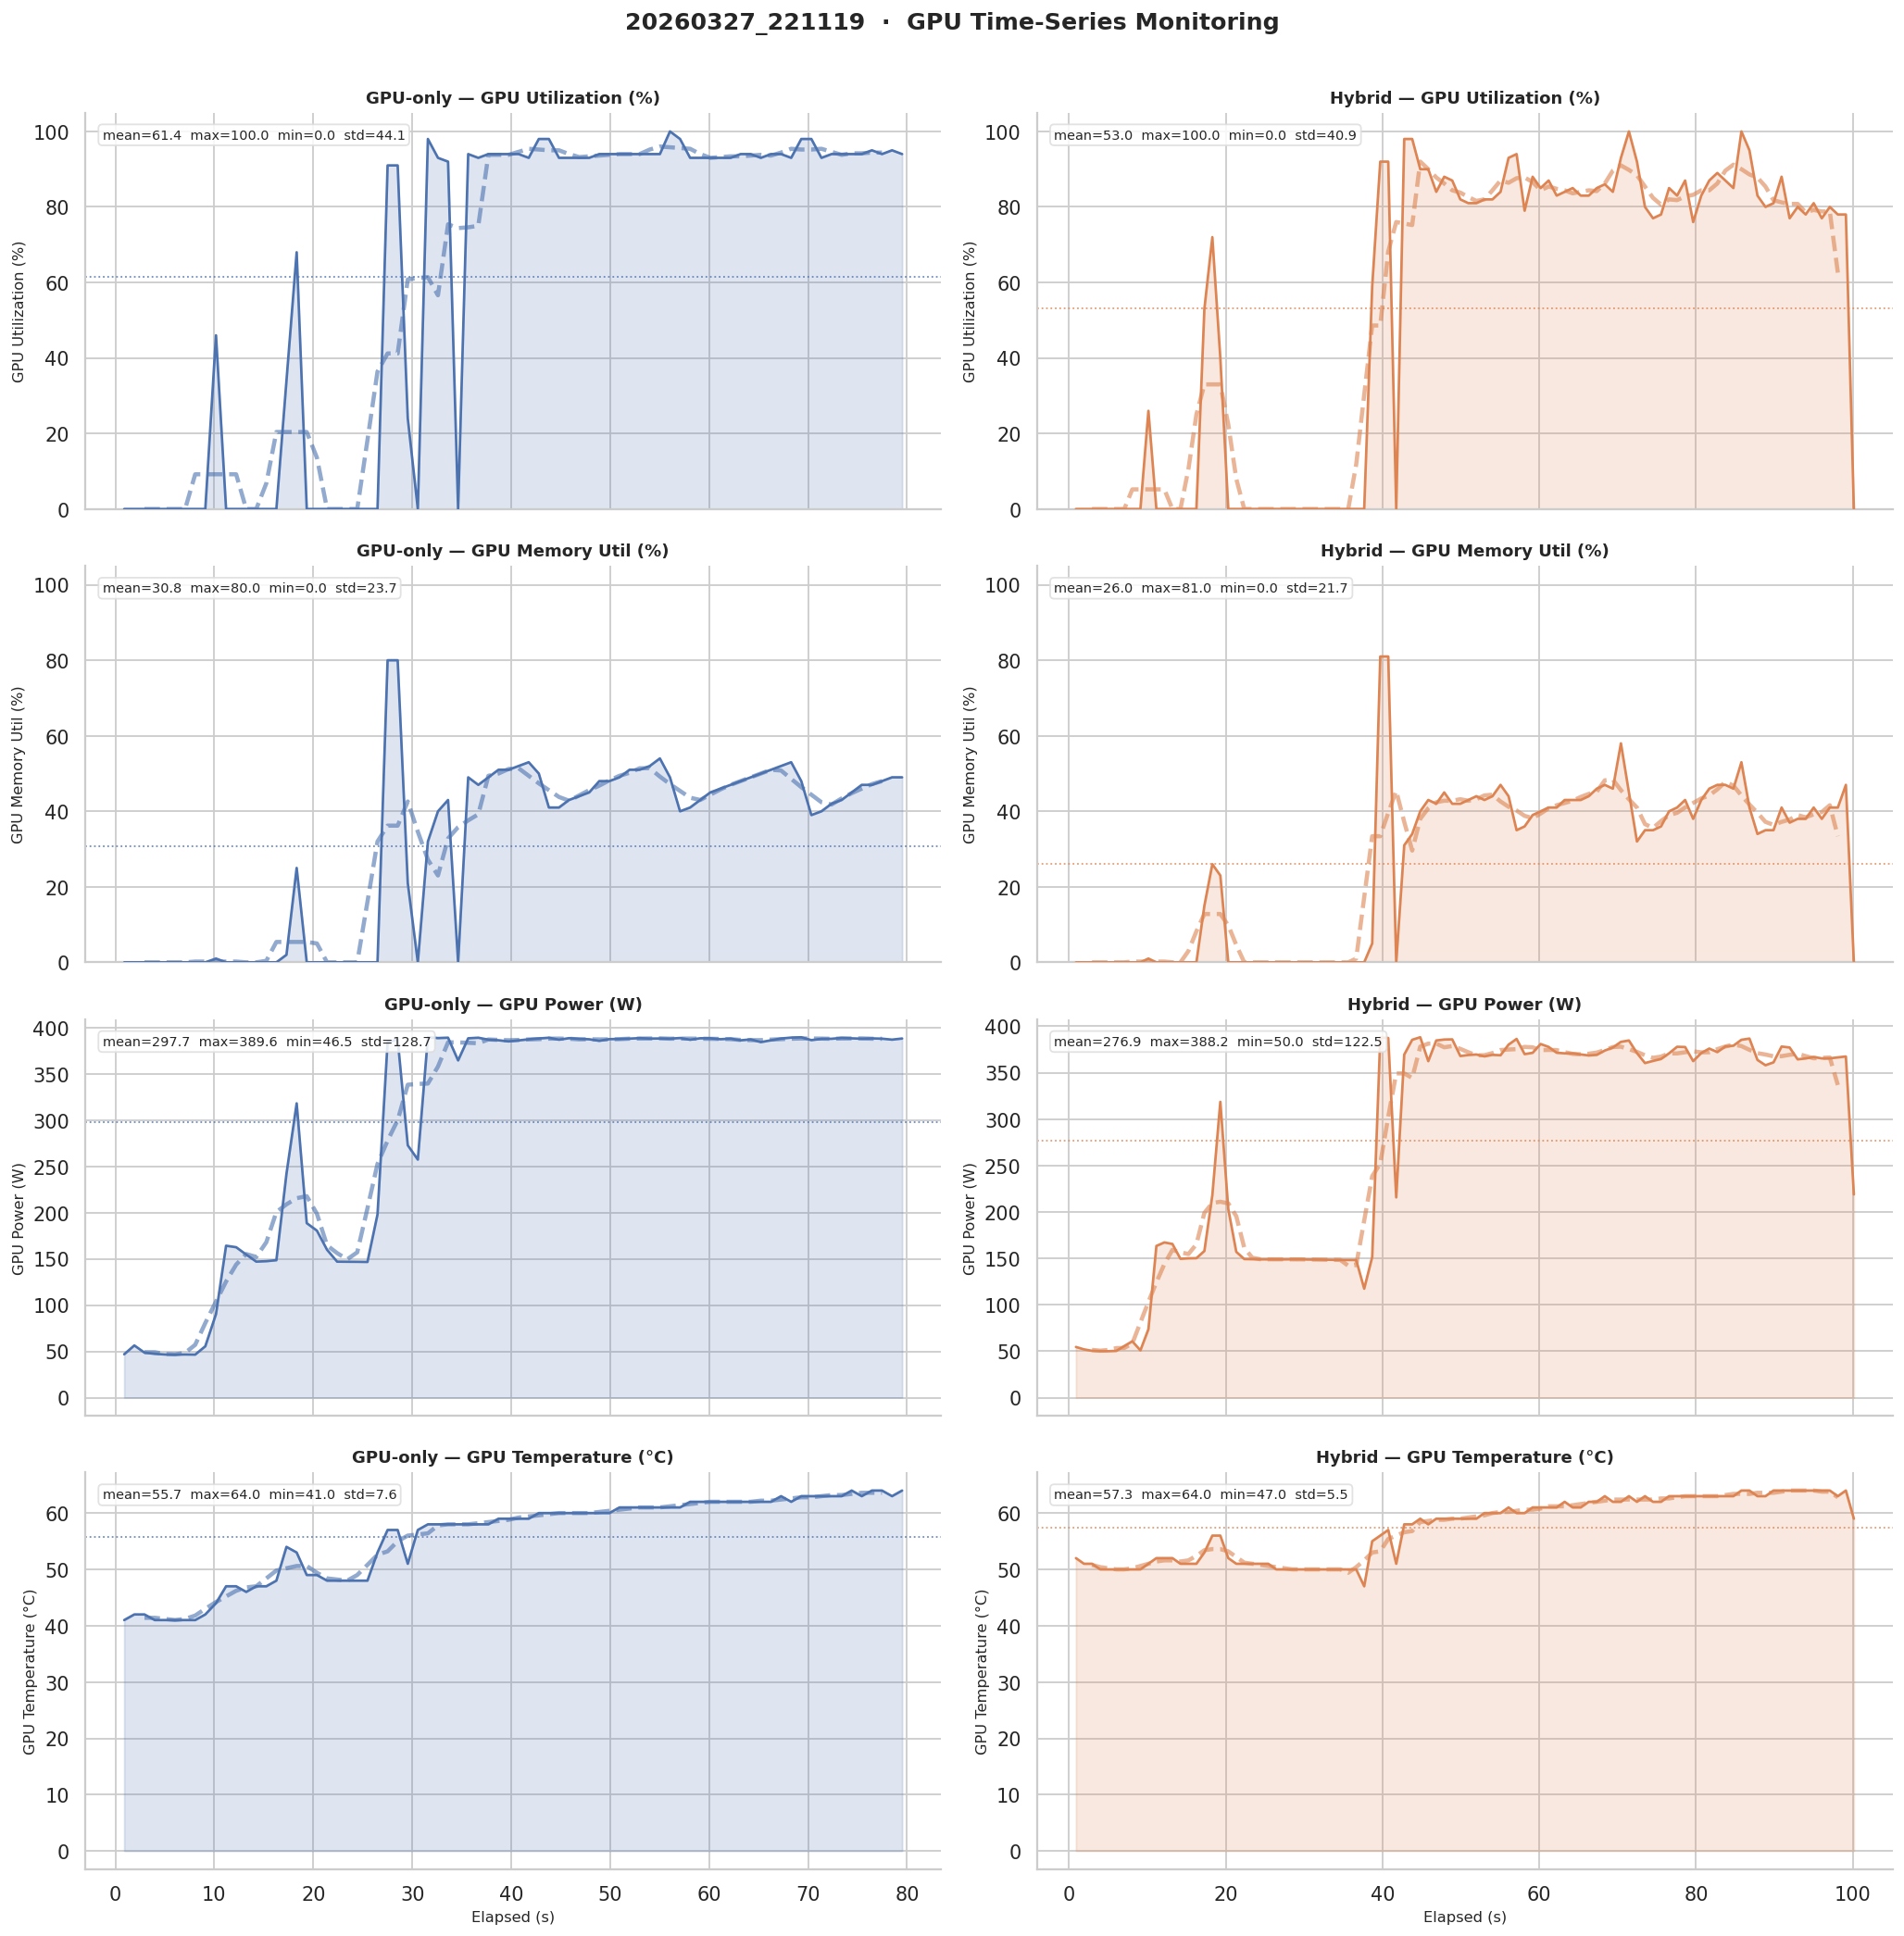

In [7]:
# ============================================================
#  6. GPU Time-Series: Utilization / Memory / Power / Temp
# ============================================================

gpu_series = [
    ('gpu_avg_util_pct',     'GPU Utilization (%)',  (0, 105)),
    ('gpu_avg_mem_util_pct', 'GPU Memory Util (%)',  (0, 105)),
    ('gpu_avg_power_w',      'GPU Power (W)',        (None, None)),
    ('gpu0_temp_c',          'GPU Temperature (°C)', (None, None)),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex='col')
fig.suptitle(f'{RUN_NAME}  ·  GPU Time-Series Monitoring',
             fontsize=14, fontweight='bold', y=1.005)

for col, (df, color, label) in enumerate([
    (g_gpu_csv, GPU_COLOR,    'GPU-only'),
    (h_gpu_csv, HYBRID_COLOR, 'Hybrid'),
]):
    for row, (cname, ylabel, ylim) in enumerate(gpu_series):
        ax = axes[row][col]
        if df is None or cname not in df.columns:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='#aaa')
            ax.set_title(f'{label} — {ylabel}', fontsize=10)
            continue
        t = df['elapsed_s']
        v_series = df[cname].dropna()

        ax.plot(t, df[cname], color=color, linewidth=1.5, zorder=3)
        ax.fill_between(t, df[cname], alpha=0.18, color=color, zorder=2)

        # moving average
        roll = df[cname].rolling(5, center=True).mean()
        ax.plot(t, roll, color=color, linewidth=2.5, alpha=0.6,
                linestyle='--', zorder=4, label='MA-5')

        # mean line
        ax.axhline(v_series.mean(), color=color, linewidth=1,
                   linestyle=':', alpha=0.8)

        if ylim[0] is not None: ax.set_ylim(*ylim)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{label} — {ylabel}', fontsize=10, fontweight='semibold')
        if row == len(gpu_series) - 1:
            ax.set_xlabel('Elapsed (s)', fontsize=9)

        stats_txt = (f'mean={v_series.mean():.1f}  '
                     f'max={v_series.max():.1f}  '
                     f'min={v_series.min():.1f}  '
                     f'std={v_series.std():.1f}')
        ax.text(0.02, 0.96, stats_txt, transform=ax.transAxes,
                va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#ddd', alpha=0.85))

sns.despine()
plt.tight_layout()
plt.show()

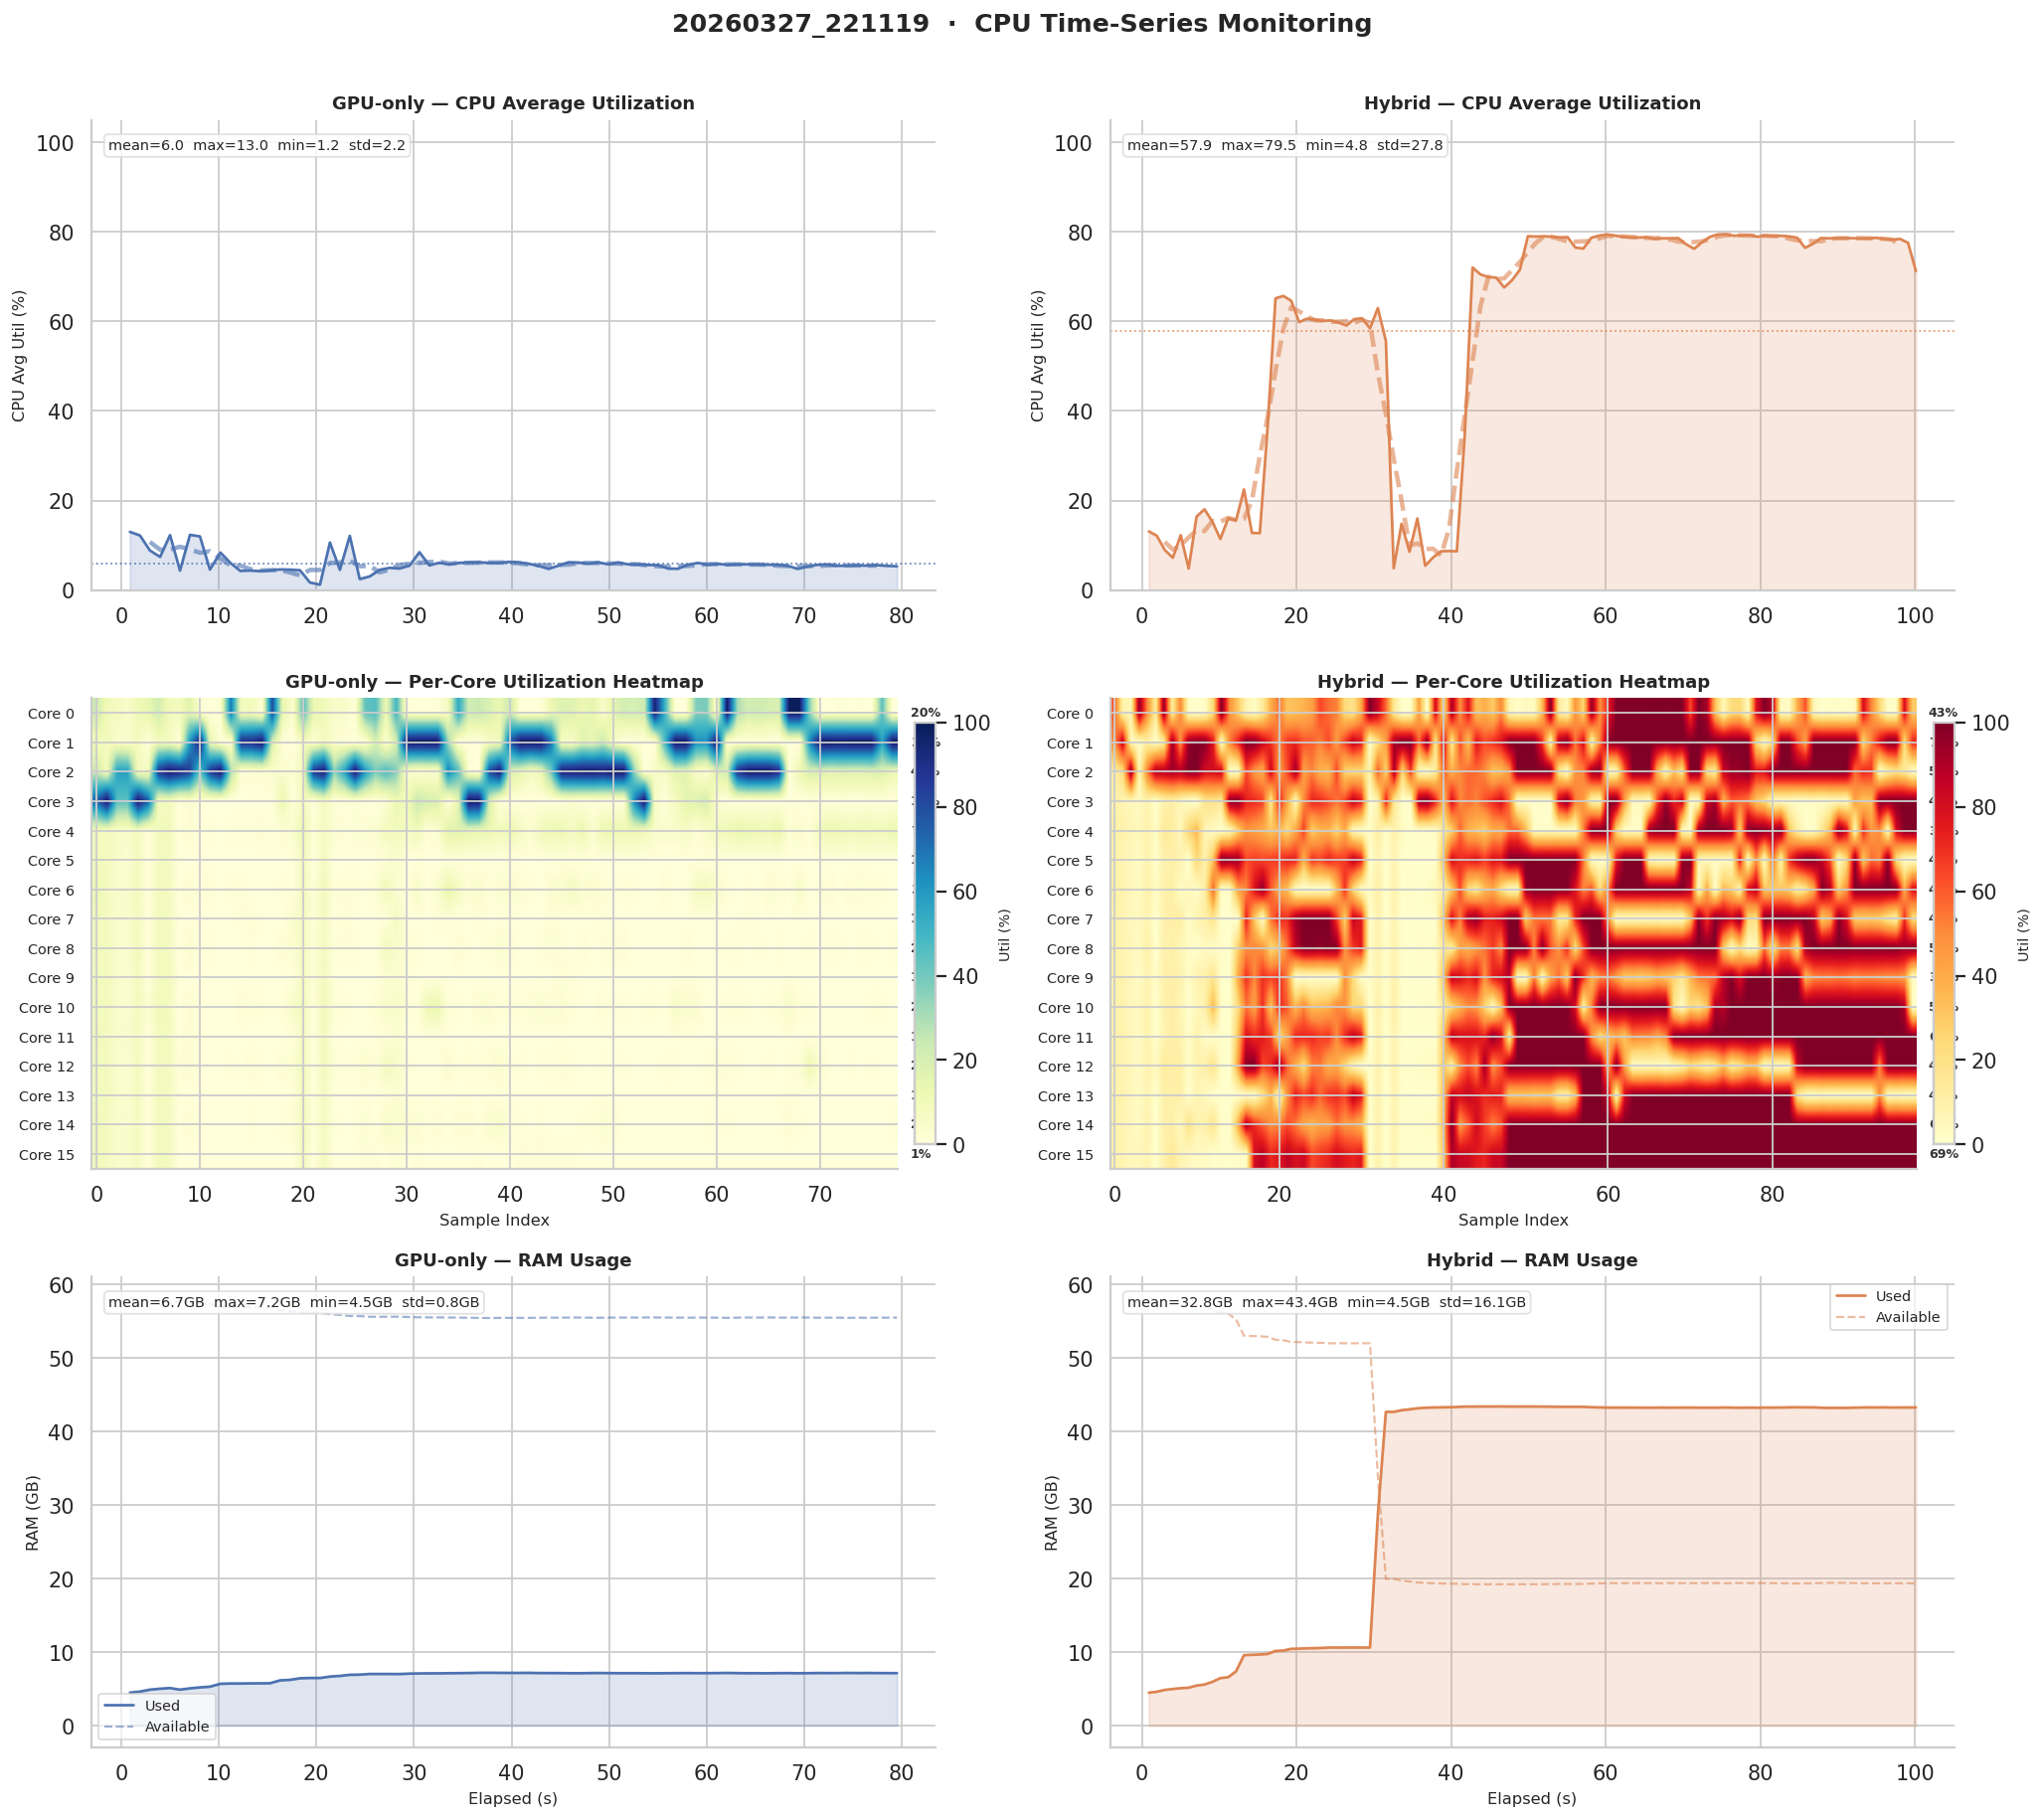

In [8]:
# ============================================================
#  7. CPU Time-Series: Avg Util / Per-Core Heatmap / RAM
# ============================================================

core_cols = [f'core{i}_util_pct' for i in range(16)]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(f'{RUN_NAME}  ·  CPU Time-Series Monitoring',
             fontsize=14, fontweight='bold', y=1.005)

for col, (df, color, label) in enumerate([
    (g_cpu_csv, GPU_COLOR,    'GPU-only'),
    (h_cpu_csv, HYBRID_COLOR, 'Hybrid'),
]):
    if df is None:
        for ax in axes[:, col]:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='#aaa')
        continue

    t  = df['elapsed_s']
    cc = [c for c in core_cols if c in df.columns]

    # ── Row 0: CPU avg utilization ────────────────────────────
    ax = axes[0][col]
    v  = df['cpu_avg_util_pct']
    ax.plot(t, v, color=color, linewidth=1.5, zorder=3)
    ax.fill_between(t, v, alpha=0.18, color=color, zorder=2)
    ax.plot(t, v.rolling(5, center=True).mean(),
            color=color, linewidth=2.5, linestyle='--', alpha=0.6, zorder=4)
    ax.axhline(v.mean(), color=color, linewidth=1, linestyle=':', alpha=0.8)
    ax.set_ylim(0, 105)
    ax.set_ylabel('CPU Avg Util (%)', fontsize=9)
    ax.set_title(f'{label} — CPU Average Utilization',
                 fontsize=10, fontweight='semibold')
    vs = v.dropna()
    ax.text(0.02, 0.96,
            f'mean={vs.mean():.1f}  max={vs.max():.1f}  min={vs.min():.1f}  std={vs.std():.1f}',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#ddd', alpha=0.85))

    # ── Row 1: per-core heatmap ───────────────────────────────
    ax = axes[1][col]
    if cc:
        cmap = 'YlOrRd' if label == 'Hybrid' else 'YlGnBu'
        im = ax.imshow(df[cc].T.values, aspect='auto', cmap=cmap,
                       vmin=0, vmax=100, interpolation='bilinear')
        ax.set_yticks(range(len(cc)))
        ax.set_yticklabels(
            [c.replace('_util_pct', '').replace('core', 'Core ') for c in cc],
            fontsize=8)
        ax.set_xlabel('Sample Index', fontsize=9)
        ax.set_title(f'{label} — Per-Core Utilization Heatmap',
                     fontsize=10, fontweight='semibold')
        cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
        cb.set_label('Util (%)', fontsize=8)
        # mean % annotations on right
        for i, mv in enumerate(df[cc].mean()):
            ax.text(df[cc].shape[0] * 1.01, i, f'{mv:.0f}%',
                    va='center', fontsize=7,
                    color='#333', fontweight='bold')

    # ── Row 2: RAM usage ─────────────────────────────────────
    ax = axes[2][col]
    if 'cpu_mem_used_mb' in df.columns:
        used_gb  = df['cpu_mem_used_mb'] / 1024
        ax.plot(t, used_gb, color=color, linewidth=1.5, label='Used', zorder=3)
        ax.fill_between(t, used_gb, alpha=0.18, color=color, zorder=2)
    if 'cpu_mem_avail_mb' in df.columns:
        avail_gb = df['cpu_mem_avail_mb'] / 1024
        ax.plot(t, avail_gb, color=color, linewidth=1.2,
                linestyle='--', alpha=0.55, label='Available', zorder=3)
    ax.set_ylabel('RAM (GB)', fontsize=9)
    ax.set_title(f'{label} — RAM Usage', fontsize=10, fontweight='semibold')
    ax.set_xlabel('Elapsed (s)', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    if 'cpu_mem_used_mb' in df.columns:
        m = used_gb.dropna()
        ax.text(0.02, 0.96,
                f'mean={m.mean():.1f}GB  max={m.max():.1f}GB  '
                f'min={m.min():.1f}GB  std={m.std():.1f}GB',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#ddd', alpha=0.85))

sns.despine()
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
#  8. Resource Utilization Stats (from comparison.json)
# ============================================================

if not comparison:
    print('comparison.json not found')
else:
    gu = comparison.get('gpu_utilization', {})
    cu = comparison.get('cpu_utilization', {})

    # ── GPU stats table ───────────────────────────────────────
    gpu_stat_keys = [
        ('gpu0_util_pct',       'GPU0 Util (%)'),
        ('gpu_avg_util_pct',    'GPU Avg Util (%)'),
        ('gpu0_mem_util_pct',   'GPU0 Mem Util (%)'),
        ('gpu_avg_mem_util_pct','GPU Avg Mem Util (%)'),
        ('gpu0_power_w',        'GPU0 Power (W)'),
        ('gpu_avg_power_w',     'GPU Avg Power (W)'),
    ]
    gpu_rows = []
    for mode, label in [('gpu_only','GPU-only'), ('hybrid','Hybrid')]:
        md  = gu.get(mode, {})
        row = {'Mode': label,
               'Samples':     md.get('sample_count', '-'),
               'Duration (s)':md.get('duration_s', '-')}
        for key, col_label in gpu_stat_keys:
            stat = md.get(key, {})
            row[f'{col_label} mean'] = stat.get('mean', np.nan)
            row[f'{col_label} max']  = stat.get('max',  np.nan)
            row[f'{col_label} min']  = stat.get('min',  np.nan)
        gpu_rows.append(row)

    display(pd.DataFrame(gpu_rows).set_index('Mode').T
        .style.format('{:.2f}', na_rep='-')
        .background_gradient(cmap='Blues', axis=1)
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','12px'),('padding','5px 10px')]}])
        .set_caption('<b style="font-size:14px">GPU Utilization Statistics</b>'))

    # ── CPU per-core stats ────────────────────────────────────
    all_core_keys = [k for k in cu.get('gpu_only', {}).keys() if k.startswith('core')]
    cpu_rows = []
    for key in all_core_keys + ['cpu_avg_util_pct']:
        row = {'Core': key.replace('_util_pct','').replace('core','Core ')}
        for mode, label in [('gpu_only','GPU-only'), ('hybrid','Hybrid')]:
            stat = cu.get(mode, {}).get(key, {})
            row[f'{label} mean'] = stat.get('mean', np.nan)
            row[f'{label} max']  = stat.get('max',  np.nan)
            row[f'{label} min']  = stat.get('min',  np.nan)
        cpu_rows.append(row)

    cpu_stat_df = pd.DataFrame(cpu_rows).set_index('Core')
    display(cpu_stat_df.style
        .format('{:.2f}', na_rep='-')
        .background_gradient(cmap='Oranges', subset=['Hybrid mean'], vmin=0, vmax=100)
        .background_gradient(cmap='Blues',   subset=['GPU-only mean'], vmin=0, vmax=100)
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','12px'),('padding','5px 10px')]},
            {'selector':'tr:nth-child(even)',
             'props':[('background-color','#fafafa')]}])
        .set_caption('<b style="font-size:14px">CPU Per-Core Utilization Statistics</b>'))

Mode,GPU-only,Hybrid
Samples,78.00,98.00
Duration (s),78.60,99.20
GPU0 Util (%) mean,61.37,53.04
GPU0 Util (%) max,100.00,100.00
GPU0 Util (%) min,0.00,0.00
GPU Avg Util (%) mean,61.37,53.04
GPU Avg Util (%) max,100.00,100.00
GPU Avg Util (%) min,0.00,0.00
GPU0 Mem Util (%) mean,30.82,26.04
GPU0 Mem Util (%) max,80.00,81.00


,GPU-only mean,GPU-only max,GPU-only min,Hybrid mean,Hybrid max,Hybrid min
Core,,,,,,
Core 0,20.26,99.00,0.00,43.28,100.00,0.00
Core 1,36.51,100.00,0.00,70.78,100.00,0.00
Core 2,41.38,100.00,0.00,58.49,100.00,0.00
Core 3,13.37,100.00,0.00,41.42,100.00,0.00
Core 4,7.20,16.70,0.00,37.43,100.00,0.00
Core 5,0.93,8.80,0.00,47.58,100.00,0.00
Core 6,2.83,13.90,0.00,43.37,100.00,0.00
Core 7,1.15,9.80,0.00,44.66,100.00,0.00
Core 8,1.65,9.70,0.00,55.43,100.00,0.00


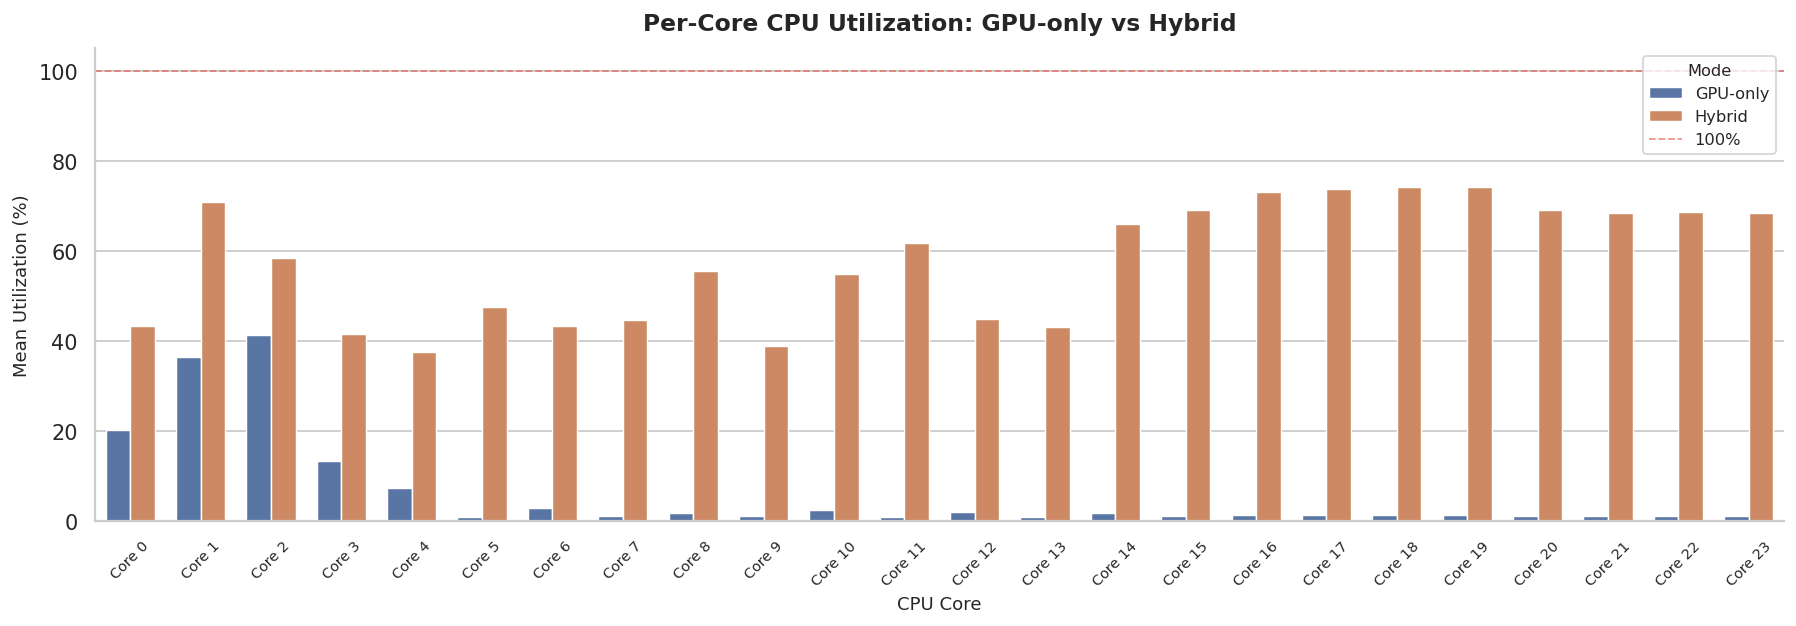

In [10]:
# ============================================================
#  9. Per-Core Utilization Bar — GPU-only vs Hybrid
# ============================================================

if comparison:
    cu = comparison.get('cpu_utilization', {})
    all_core_keys = [k for k in cu.get('gpu_only', {}).keys() if k.startswith('core')]

    core_bar_rows = []
    for key in all_core_keys:
        core_id = key.replace('_util_pct','').replace('core','Core ')
        for mode, label in [('gpu_only','GPU-only'), ('hybrid','Hybrid')]:
            mean_v = cu.get(mode, {}).get(key, {}).get('mean', np.nan)
            core_bar_rows.append({'Core': core_id, 'Mode': label, 'Mean Util (%)': mean_v})

    core_bar_df = pd.DataFrame(core_bar_rows)

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=core_bar_df, x='Core', y='Mean Util (%)',
                hue='Mode', palette=PALETTE, ax=ax,
                edgecolor='white', linewidth=0.8, width=0.7)
    ax.set_ylim(0, 105)
    ax.axhline(100, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.6, label='100%')
    ax.set_xlabel('CPU Core', fontsize=10)
    ax.set_ylabel('Mean Utilization (%)', fontsize=10)
    ax.set_title('Per-Core CPU Utilization: GPU-only vs Hybrid',
                 fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(title='Mode', fontsize=9, title_fontsize=9)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print('comparison.json not found')

,Avg Power (W),Output TP (tok/s),Efficiency (tok/s/W)
Mode,,,
GPU-only,297.680,9737.771,32.712
Hybrid,276.920,8455.977,30.536


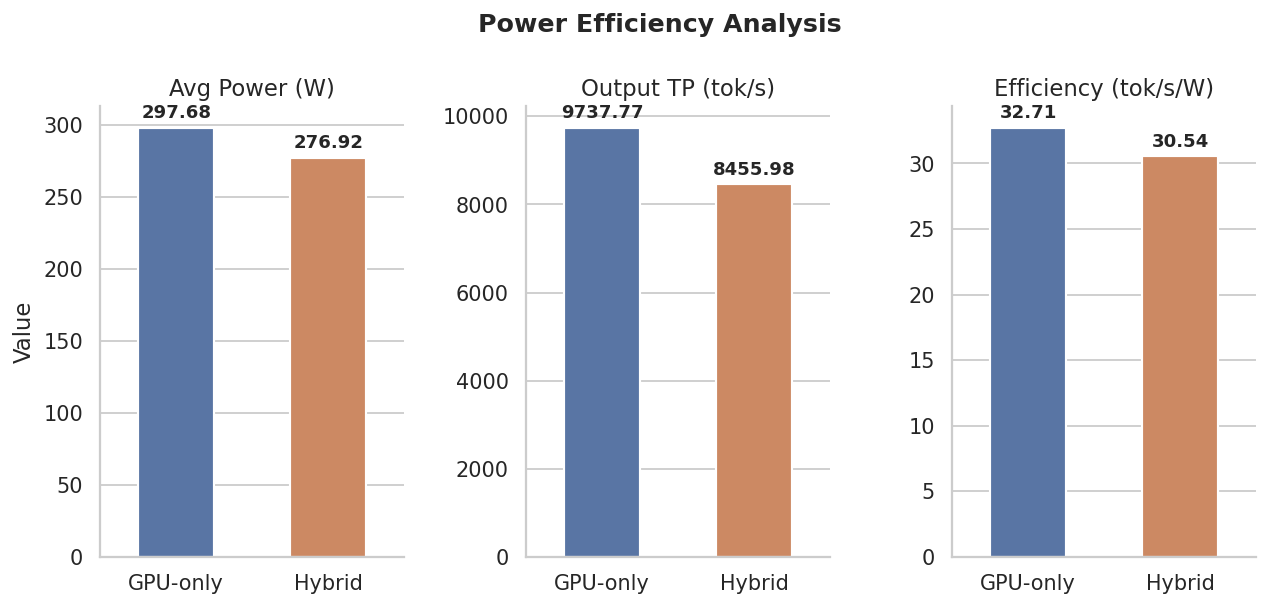

In [11]:
# ============================================================
#  10. Power Efficiency (tok/s per Watt)
# ============================================================

if not comparison:
    print('comparison.json not found')
else:
    gu    = comparison.get('gpu_utilization', {})
    g_pw  = gu.get('gpu_only', {}).get('gpu_avg_power_w', {}).get('mean', np.nan)
    h_pw  = gu.get('hybrid',   {}).get('gpu_avg_power_w', {}).get('mean', np.nan)
    g_out = (gpu_only or {}).get('output_throughput', np.nan)
    h_out = (hybrid   or {}).get('output_throughput', np.nan)
    g_eff = g_out / g_pw if g_pw else np.nan
    h_eff = h_out / h_pw if h_pw else np.nan

    eff_data = pd.DataFrame([
        {'Mode':'GPU-only','Avg Power (W)':g_pw,'Output TP (tok/s)':g_out,'Efficiency (tok/s/W)':g_eff},
        {'Mode':'Hybrid',  'Avg Power (W)':h_pw,'Output TP (tok/s)':h_out,'Efficiency (tok/s/W)':h_eff},
    ])

    display(eff_data.set_index('Mode').style
        .format('{:.3f}', na_rep='-')
        .background_gradient(cmap='Greens', subset=['Efficiency (tok/s/W)'])
        .set_caption('<b style="font-size:14px">Power Efficiency Summary</b>')
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','12px'),('padding','5px 10px')]}]))

    metrics = ['Avg Power (W)', 'Output TP (tok/s)', 'Efficiency (tok/s/W)']
    eff_long = eff_data.melt(id_vars='Mode', value_vars=metrics,
                              var_name='Metric', value_name='Value')

    g = sns.FacetGrid(eff_long, col='Metric', height=4.5, aspect=0.85,
                      sharey=False, gridspec_kws={'wspace': 0.4})

    def draw_eff(data, **kw):
        ax = plt.gca()
        sns.barplot(data=data, x='Mode', y='Value', palette=PALETTE,
                    order=['GPU-only','Hybrid'], ax=ax,
                    edgecolor='white', linewidth=1.2, width=0.5)
        for patch in ax.patches:
            v = patch.get_height()
            if not np.isnan(v) and v > 0:
                ax.text(patch.get_x() + patch.get_width()/2,
                        v * 1.015, f'{v:.2f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    g.map_dataframe(draw_eff)
    g.set_axis_labels('', 'Value')
    g.set_titles(col_template='{col_name}')
    g.figure.suptitle('Power Efficiency Analysis',
                       fontsize=14, fontweight='bold', y=1.04)
    sns.despine()
    plt.show()

In [12]:
# ============================================================
#  11. Raw Data Preview (describe)
# ============================================================

for name, df in [('GPU-only GPU monitor', g_gpu_csv),
                 ('Hybrid GPU monitor',   h_gpu_csv),
                 ('GPU-only CPU monitor', g_cpu_csv),
                 ('Hybrid CPU monitor',   h_cpu_csv)]:
    if df is None: continue
    print(f'\n{name}: {len(df)} rows × {len(df.columns)} cols')
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    display(df[numeric_cols].describe().T
        .style.format('{:.2f}', na_rep='-')
        .background_gradient(cmap='coolwarm', subset=['mean'], axis=0)
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','11px'),('padding','4px 8px')]}])
        .set_caption(f'<b>{name} — describe()</b>'))


GPU-only GPU monitor: 78 rows × 10 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,78.00,40.24,23.12,0.90,20.63,40.24,59.86,79.50
gpu0_util_pct,78.00,61.37,44.06,0.00,0.00,93.00,94.00,100.00
gpu0_mem_util_pct,78.00,30.82,23.70,0.00,0.00,43.00,49.00,80.00
gpu0_mem_used_mb,78.00,18343.46,8583.15,38.00,22680.00,22680.00,22680.00,22680.00
gpu0_power_w,78.00,297.68,128.72,46.52,162.99,386.84,388.12,389.55
gpu0_temp_c,78.00,55.73,7.57,41.00,48.00,59.00,62.00,64.00
gpu_avg_util_pct,78.00,61.37,44.06,0.00,0.00,93.00,94.00,100.00
gpu_avg_mem_util_pct,78.00,30.82,23.70,0.00,0.00,43.00,49.00,80.00
gpu_avg_power_w,78.00,297.68,128.72,46.52,162.99,386.84,388.12,389.55



Hybrid GPU monitor: 98 rows × 10 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,98.00,50.48,29.08,0.90,25.68,50.44,75.27,100.13
gpu0_util_pct,98.00,53.04,40.90,0.00,0.00,79.50,85.00,100.00
gpu0_mem_util_pct,98.00,26.04,21.68,0.00,0.00,35.50,43.00,81.00
gpu0_mem_used_mb,98.00,19017.35,8027.10,38.00,22680.00,22680.00,22680.00,22680.00
gpu0_power_w,98.00,276.92,122.52,50.04,149.19,365.08,372.04,388.23
gpu0_temp_c,98.00,57.35,5.54,47.00,51.00,59.00,63.00,64.00
gpu_avg_util_pct,98.00,53.04,40.90,0.00,0.00,79.50,85.00,100.00
gpu_avg_mem_util_pct,98.00,26.04,21.68,0.00,0.00,35.50,43.00,81.00
gpu_avg_power_w,98.00,276.92,122.52,50.04,149.19,365.08,372.04,388.23



GPU-only CPU monitor: 78 rows × 29 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,78.00,40.24,23.12,0.90,20.63,40.24,59.86,79.50
core0_util_pct,78.00,20.26,24.89,0.00,1.92,12.80,22.73,99.00
core1_util_pct,78.00,36.51,42.25,0.00,1.00,8.80,91.20,100.00
core2_util_pct,78.00,41.38,38.09,0.00,7.80,20.90,86.85,100.00
core3_util_pct,78.00,13.37,27.50,0.00,0.00,0.00,11.38,100.00
core4_util_pct,78.00,7.20,4.69,0.00,2.92,8.30,10.88,16.70
core5_util_pct,78.00,0.93,2.50,0.00,0.00,0.00,0.00,8.80
core6_util_pct,78.00,2.83,3.30,0.00,0.00,1.95,3.90,13.90
core7_util_pct,78.00,1.15,2.55,0.00,0.00,0.00,1.00,9.80
core8_util_pct,78.00,1.65,2.59,0.00,0.00,1.00,1.90,9.70



Hybrid CPU monitor: 98 rows × 29 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,98.00,50.48,29.08,0.90,25.68,50.44,75.27,100.13
core0_util_pct,98.00,43.28,35.86,0.00,6.38,37.85,78.28,100.00
core1_util_pct,98.00,70.78,33.14,0.00,52.12,79.90,100.00,100.00
core2_util_pct,98.00,58.49,35.86,0.00,25.15,60.50,96.60,100.00
core3_util_pct,98.00,41.42,36.80,0.00,3.15,40.40,73.05,100.00
core4_util_pct,98.00,37.43,36.69,0.00,4.15,27.60,57.38,100.00
core5_util_pct,98.00,47.58,39.64,0.00,4.12,57.10,79.90,100.00
core6_util_pct,98.00,43.37,38.89,0.00,5.45,31.90,87.80,100.00
core7_util_pct,98.00,44.66,39.61,0.00,7.80,29.05,84.22,100.00
core8_util_pct,98.00,55.43,41.00,0.00,9.75,53.20,100.00,100.00
